# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-5: Creación y medición del estado de Bell (Qiskit)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-5.

Equivalente en Qiskit del Listing 3-4 (Cirq). El estado de Bell $|\Phi^+\rangle$ se construye con Hadamard + CNOT:

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)$$

Al medir solo aparecen |00⟩ y |11⟩ — evidencia del entrelazamiento cuántico.

### Diferencias de API respecto al libro (Qiskit 1.0+)

| Libro (API antigua) | Este notebook (Qiskit ≥1.0) |
|---|---|
| `from qiskit import execute, Aer` | `from qiskit_aer import AerSimulator` |
| `Aer.get_backend('qasm_simulator')` | `AerSimulator()` |
| `execute(circuit, simulator, shots=n)` | `simulator.run(transpile(circuit, simulator), shots=n)` |

### Definición del circuito

In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# 2 qubits, 2 bits clásicos para almacenar las mediciones
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)  # CNOT: control=0, objetivo=1
circuit.measure([0, 1], [0, 1])

print(circuit.draw(output='text'))

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


### Visualización del circuito

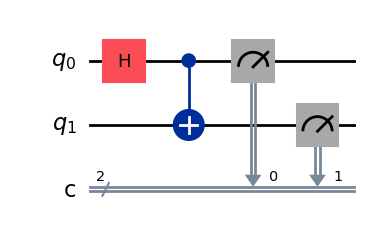

In [2]:
circuit.draw('mpl')

### Simulación

In [3]:
simulator = AerSimulator()
compiled = transpile(circuit, simulator)
job = simulator.run(compiled, shots=100)
result = job.result()
counts = result.get_counts()

print("Conteo total para |00⟩ y |11⟩:", counts)

Conteo total para |00⟩ y |11⟩: {'00': 44, '11': 56}


### Histograma de mediciones

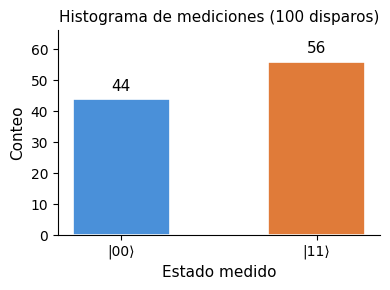

In [4]:
from qml_santanu.common.plot_utils import plot_counts

plot_counts(counts)